In [1]:
import os

os.environ["ROCM_HOME"] = "/opt/rocm"

import numpy as np
import cupy as cp
import scipy
import cupyx.scipy as cpscipy
from cupyx.scipy.sparse.linalg import factorized
import matplotlib.pyplot as plt
import sys
import requests
import tarfile
import shutil
import time

cp.cuda.runtime.setDevice(0)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

ModuleNotFoundError: No module named 'cupy'

In [8]:
properties = cp.cuda.runtime.getDeviceProperties(0)
print(properties['name'].decode('utf-8'))

AMD Instinct MI210


In [11]:
with open("A.tar.gz", "wb") as file:
    request = requests.get("https://suitesparse-collection-website.herokuapp.com/MM/GHS_psdef/torsion1.tar.gz")
    file.write(request.content)
with tarfile.open("A.tar.gz", "r:gz") as tar:
    mtx = tar.getmembers()[0]
    with tar.extractfile(mtx) as file_in:
      with open("A.mtx", "wb") as file_out:
        shutil.copyfileobj(file_in, file_out)

# with open("b.tar.gz", "wb") as file:
#     request = requests.get("https://suitesparse-collection-website.herokuapp.com/MM/FIDAP/ex15.tar.gz")
#     file.write(request.content)
# with tarfile.open("b.tar.gz", "r:gz") as tar:
#     mtx = tar.getmembers()[0]
#     with tar.extractfile(mtx) as file_in:
#       with open("b.mtx", "wb") as file_out:
#         shutil.copyfileobj(file_in, file_out)

# with open("J.mtx", "wb") as file:
#     request = requests.get("https://raw.githubusercontent.com/ORNL/ReSolve/refs/heads/develop/tests/unit/hykkt/SCCGTestMatrices/JC_matrix_ACTIVSg200_AC_00.mtx")
#     file.write(request.content)
# with open("H.mtx", "wb") as file:
#     request = requests.get("https://raw.githubusercontent.com/ORNL/ReSolve/refs/heads/develop/tests/unit/hykkt/SCCGTestMatrices/H_matrix_ACTIVSg200_AC_00.mtx")
#     file.write(request.content)
# with open("b.mtx", "wb") as file:
#     request = requests.get("https://raw.githubusercontent.com/ORNL/ReSolve/refs/heads/develop/tests/unit/hykkt/SCCGTestMatrices/CG_rhs_ACTIVSg200_AC_00.mtx")
#     file.write(request.content)

# # read data
# filename = "b.mtx"8
# with open(filename) as f:
#     data = f.readlines()

# # modify
# data[0] = "%%MatrixMarket matrix array real general\n"
# data.insert(1, "%% Generated 13-May-2021\n")

# #write
# with open(filename, 'w') as f:
#     f.writelines(data)

NameError: name 'requests' is not defined

In [ ]:
# scaling tests

n = A.shape[0]

D = cp.diag(1 / cp.sqrt(A.diagonal())) # Diagonal scaling matrix
A_bar = D @ A @ D

b_norm = cp.linalg.norm(b)
b_bar = 1 / b_norm * (D @ b) #  https://arxiv.org/pdf/1610.03871

rng = np.random.default_rng(seed=1234567)

B = cp.tile(b, (1, k))
B_bar = cp.tile(b_bar, (1, k))

U = cp.random.uniform(-1, 1, (n, k))
# U = cp.asarray(rng.normal(0, 1, (n, k)))
# Q, R = cp.linalg.qr(U)
X_bar = U
X = b_norm * D @ X_bar
X_bar_ = B.std() / (A @ X).std() * X_bar
X = b_norm * D @ X_bar_

In [125]:
# This replicates the ReSolve code (but simplifies some logic)
ITMAX=2000
A = A
b = b
n = A.shape[0]

D = cpscipy.sparse.diags(1 / cp.sqrt(A.diagonal())) # Diagonal scaling matrix
A_bar = D @ A @ D

b_norm = cp.linalg.norm(b)
b_bar = 1 / b_norm * (D @ b) #  https://arxiv.org/pdf/1610.03871

np_rng = np.random.default_rng(seed=1234567)

ITMAX = ITMAX

cp_rng = cp.random.RandomState(seed=1234)
k=2
beta=1e4
penalty = cp.sqrt(beta) * cp.ones((1, k))

eps = sys.float_info.epsilon
assert(beta * n * eps < 0.02)

B = cp.tile(b, (1, k))
B_bar = cp.tile(b_bar, (1, k))

U = cp_rng.uniform(-1, 1, (n, k))
X_bar = U
scale_factor = cp.linalg.norm(B_bar) / cp.linalg.norm(A_bar @ X_bar)
X_bar = X_bar * scale_factor
X = b_norm * D @ X_bar

# X_bar = cp.zeros((n, k))
# X_bar[::2, 0] = -0.0009139
# X_bar[1::2, 0] = 0.01654918
# X_bar[::4, 1] = -0.0009139
# X_bar[1::4, 1] = -0.0009139
# X_bar[2::4, 1] = 0.01654918
# X_bar[3::4, 1] = 0.01654918
# X = b_norm * D @ X_bar

TOL = 1e-12

R_bar = B_bar - A_bar @ X_bar
P = R_bar # Nonzero X_0 => use P = R_bar instead of P = B_bar]
Gamma_i = R_bar.T @ R_bar

converged = False
error = 999999
error_history = []
for i in range(ITMAX):
    Delta = P.T @ A_bar @ P
    Delta_inv = cp.linalg.inv(Delta)
    Alpha = Delta_inv @ Gamma_i
    X_bar = X_bar + P @ Alpha
    R_bar = R_bar - A_bar @ P @ Alpha

    X = b_norm * D @ X_bar
    if k == 1:
        x = X
    else:
        # Find optimal linear combination of the columns of X
        AX_with_penalty = cp.vstack([A @ X, penalty])
        b_with_penalty = cp.vstack([b, cp.sqrt(beta)])
        cp.random.seed(1234)
        c, _, _, _ = cp.linalg.lstsq(AX_with_penalty, b_with_penalty)
        x = X @ c

    r = b - A @ x
    # error = cp.linalg.norm(r)
    error = cp.linalg.norm(r) / b_norm
    error_history.append(error)
    print(f"iteration {i}, error {error}")
    if (error < TOL):
        converged = True
        print(f"Converged in {i + 1} iterations. Error: {min_norm}")
        break

    Gamma_i1 = R_bar.T @ R_bar
    Gamma_i_inv = cp.linalg.inv(Gamma_i)
    Beta = Gamma_i_inv @ Gamma_i1
    Gamma_i = Gamma_i1
    P = R_bar + P @ Beta

if not converged:
    i = -1
    # print("Didn't converge.")

basis_errors = cp.linalg.norm(cp.tile(b, (1, k)) - A @ X, axis=0)
# print(f"Error of final linear combination solution: {error}")
# print(f"Errors of each individual column of X_bar: {cp.linalg.norm(basis_errors, axis=0)}")
# return (i, error, basis_errors, error_history, X_bar @ c)

NameError: name 'b' is not defined

In [ ]:
X_bar

array([[ 2.06584496e-03,  2.06584496e-03],
       [ 8.35850401e-05,  8.35850401e-05],
       [ 6.33898187e-04,  6.33898187e-04],
       ...,
       [ 2.51692100e-05,  2.51692100e-05],
       [ 1.70347425e-02,  1.70347425e-02],
       [-1.24108280e-05, -1.24108280e-05]])

In [ ]:
A_bar @ X_bar

array([[2.20614845e-05, 2.24461583e-05],
       [4.80477610e-06, 4.77982151e-06],
       [5.75492579e-06, 5.74327332e-06],
       ...,
       [5.80724370e-07, 5.64518303e-07],
       [1.70348801e-02, 1.70348852e-02],
       [1.98622363e-06, 1.89756892e-06]])

In [ ]:
B_bar

array([[5.91924400e-06, 5.91924400e-06],
       [5.65301434e-06, 5.65301434e-06],
       [5.58226583e-06, 5.58226583e-06],
       ...,
       [5.79276016e-07, 5.79276016e-07],
       [1.70347425e-02, 1.70347425e-02],
       [1.68525546e-06, 1.68525546e-06]])

In [ ]:
cp.percentile(X_bar, [5, 95])

array([-0.0009139 ,  0.01654918])

## Proper code

In [ ]:
class RandomizedCG:
    def __init__(self, A, b, ITMAX=50):
        self.A = A
        self.b = b
        self.n = self.A.shape[0]

        self.A_norm = cpscipy.sparse.linalg.norm(A)
        self.D = cpscipy.sparse.diags(1 / cp.sqrt(self.A.diagonal())) # Diagonal scaling matrix
        self.A_bar = self.D @ self.A @ self.D

        self.b_norm = cp.linalg.norm(self.b)
        self.b_bar = 1 / self.b_norm * (self.D @ self.b) #  https://arxiv.org/pdf/1610.03871

        self.np_rng = np.random.default_rng(seed=1234567)

        self.ITMAX = ITMAX

    def reset_rng(self):
        self.cp_rng = cp.random.RandomState(seed=1234)

    def generate_initial_guess(self, B_bar, mode):
        k = B_bar.shape[1]
        match mode:
            case "estimated_norm":
                U = self.cp_rng.uniform(-1, 1, (self.n, k))
                X_bar = U
                X_bar = X_bar * cp.linalg.norm(B_bar) / cp.linalg.norm(self.A_bar @ X_bar)
            case "norm_scaling":
                U = self.cp_rng.uniform(-1, 1, (self.n, k))
                X_bar = U
                X_bar = X_bar / (cp.linalg.norm(X_bar) * cp.linalg.norm(B_bar) / cp.linalg.norm(self.A_bar))
            case "hadamard":
                rows = cp.arange(n)[:, cp.newaxis]
                cols = cp.arange(k)
                X_bar = (rows & (1 << cols) > 0).astype(cp.float64)
                X_bar *= (max - min)
                X_bar += min
                print(X_bar)

        return X_bar


    def solve(self, k, beta, guess_mode):
        self.reset_rng()

        penalty = cp.sqrt(beta) * cp.ones((1, k))

        eps = sys.float_info.epsilon
        # beta = 0.02 / (self.n * eps) # maximize beta
        assert(beta * self.n * eps < 0.02)

        B_bar_tiled = cp.tile(self.b_bar, (1, k))
        X_bar_0 = self.generate_initial_guess(B_bar_tiled, guess_mode)
        X_bar = cp.zeros((self.n, k))
        B_bar = B_bar_tiled - self.A_bar @ X_bar_0
        B_tiled = cp.tile(self.b, (1, k))
        # X_bar_tiled = X_bar + X_bar_0
        # X = self.b_norm * self.D @ X_bar_tiled

        TOL = 1e-999

        R_bar = B_bar - self.A_bar @ X_bar
        Gamma_i = R_bar.T @ R_bar
        P = R_bar # Nonzero X_0 => use P = R_bar instead of P = B_bar]

        converged = False
        error = 999999
        error_history = []
        for i in range(self.ITMAX):
            Delta = P.T @ self.A_bar @ P
            Delta_inv = cp.linalg.inv(Delta)
            Alpha = Delta_inv @ Gamma_i
            X_bar = X_bar + P @ Alpha
            R_bar = R_bar - self.A_bar @ P @ Alpha

            X_bar_tiled = X_bar + X_bar_0
            X = self.b_norm * self.D @ X_bar_tiled
            if k == 1:
                x = X
            else:
                # Find optimal linear combination of the columns of X
                AX_with_penalty = cp.vstack([self.A @ X, penalty])
                b_with_penalty = cp.vstack([self.b, cp.sqrt(beta)])
                cp.random.seed(1234)
                c, _, _, _ = cp.linalg.lstsq(AX_with_penalty, b_with_penalty)
                x = X @ c

            r = self.b - self.A @ x
            # error = cp.linalg.norm(r)
            error = cp.linalg.norm(r) / (self.A_norm * cp.linalg.norm(x))
            error_history = np.append(error_history, error)
            # print(f"iteration {i}, error {error}")
            if (cp.isnan(error)):
                break
            # if (i > 50 and error < 1e-8 and error_history[-50] / error < 1.01):
            #     break
            if (error < TOL):
                converged = True
                # print(f"Converged in {i + 1} iterations. Error: {min_norm}")
                break

            Gamma_i1 = R_bar.T @ R_bar
            Gamma_i_inv = cp.linalg.inv(Gamma_i)
            Beta = Gamma_i_inv @ Gamma_i1
            Gamma_i = Gamma_i1
            P = R_bar + P @ Beta

        # if not converged:
        #     i = -1
            # print("Didn't converge.")

        basis_errors = cp.linalg.norm(cp.tile(self.b, (1, k)) - self.A @ X, axis=0)
        # print(f"Error of final linear combination solution: {error}")
        # print(f"Errors of each individual column of X_bar: {cp.linalg.norm(basis_errors, axis=0)}")
        return (i, error, basis_errors, error_history, x)

In [ ]:
class DubrelleRRandomizedCG:
    def __init__(self, A, b, ITMAX=50):
        self.A = A
        self.b = b
        self.n = self.A.shape[0]

        # self.A_norm = cpscipy.sparse.linalg.norm(A)
        self.D = cpscipy.sparse.diags(1 / cp.sqrt(self.A.diagonal())) # Diagonal scaling matrix
        self.A_bar = self.D @ self.A @ self.D

        self.b_norm = cp.linalg.norm(self.b)
        self.b_bar = 1 / self.b_norm * (self.D @ self.b) #  https://arxiv.org/pdf/1610.03871

        self.np_rng = np.random.default_rng(seed=1234567)

        self.ITMAX = ITMAX

    def reset_rng(self):
        self.cp_rng = cp.random.RandomState(seed=1234)

    def generate_initial_guess(self, B_bar, mode):
        k = B_bar.shape[1]
        match mode:
            case "estimated_norm":
                U = self.cp_rng.uniform(-1, 1, (self.n, k))
                X_bar = U
                X_bar = X_bar * cp.linalg.norm(B_bar) / cp.linalg.norm(self.A_bar @ X_bar)
            case "norm_scaling":
                U = self.cp_rng.uniform(-1, 1, (self.n, k))
                X_bar = U
                X_bar = X_bar / (cp.linalg.norm(X_bar) * cp.linalg.norm(B_bar) / cp.linalg.norm(self.A_bar))
            case "hadamard":
                rows = cp.arange(n)[:, cp.newaxis]
                cols = cp.arange(k)
                X_bar = (rows & (1 << cols) > 0).astype(cp.float64)
                X_bar *= (max - min)
                X_bar += min
                print(X_bar)

        return X_bar


    def solve(self, k, beta, guess_mode):
        self.reset_rng()
        start_time = time.perf_counter()

        penalty = cp.sqrt(beta) * cp.ones((1, k))

        eps = sys.float_info.epsilon
        # beta = 0.02 / (self.n * eps) # maximize beta
        assert(beta * self.n * eps < 0.02)

        B_bar_tiled = cp.tile(self.b_bar, (1, k))
        X_bar_0 = self.generate_initial_guess(B_bar_tiled, guess_mode)
        X_bar = cp.zeros((self.n, k))
        B_bar = B_bar_tiled - self.A_bar @ X_bar_0
        B_tiled = cp.tile(self.b, (1, k))
        # X_bar_tiled = X_bar + X_bar_0
        # X = self.b_norm * self.D @ X_bar_tiled
        
        b_with_penalty = cp.vstack([self.b, cp.sqrt(beta)])

        TOL = 1e-999

        R_bar = B_bar - self.A_bar @ X_bar
        Omega, Sigma = cp.linalg.qr(R_bar)
        P = Omega # Nonzero X_0 => use P = R_bar instead of P = B_bar]

        converged = False
        error = 999999
        error_history = []
        for i in range(self.ITMAX):
            Xi = cp.linalg.inv(P.T @ self.A_bar @ P)
            X_bar = X_bar + P @ Xi @ Sigma
            Omega, Zeta = cp.linalg.qr(Omega - self.A_bar @ P @ Xi)

            X_bar_tiled = X_bar + X_bar_0
            X = self.b_norm * self.D @ X_bar_tiled
            if k == 1:
                x = X
            else:
                # Find optimal linear combination of the columns of X
                AX_with_penalty = cp.vstack([self.A @ X, penalty])
                c, _, _, _ = cp.linalg.lstsq(AX_with_penalty, b_with_penalty)
                x = X @ c

            r = self.b - self.A @ x
            error = cp.linalg.norm(r) / self.b_norm
            # error = cp.linalg.norm(r) / (self.A_norm * cp.linalg.norm(x) + self.b_norm)
            error_history = np.append(error_history, error)
            # print(f"iteration {i}, error {error}")
            if (i > 50 and error < 1e-8 and error_history[-50] / error < 1.01):
                break
            if (cp.isnan(error)):
                break
            if (error < TOL):
                converged = True
                # print(f"Converged in {i + 1} iterations. Error: {min_norm}")
                break

            P = Omega + P @ Zeta.T
            Sigma = Zeta @ Sigma

        # if not converged:
        #     i = -1
            # print("Didn't converge.")
        end_time = time.perf_counter()

        basis_errors = cp.linalg.norm(cp.tile(self.b, (1, k)) - self.A @ X, axis=0)
        # print(f"Error of final linear combination solution: {error}")
        # print(f"Errors of each individual column of X_bar: {cp.linalg.norm(basis_errors, axis=0)}")
        return (i, error, basis_errors, error_history, x, end_time - start_time)

In [ ]:
# Run experiments and plot

def expand_symmetric(matrix):
    rows = np.concatenate([matrix.row, matrix.col])
    cols = np.concatenate([matrix.col, matrix.row])
    vals = np.concatenate([matrix.data, matrix.data])
    return scipy.sparse.coo_array((vals, (rows, cols)), shape=matrix.shape)

def run_experiment(matrix_name, beta, ITMAX, ks):
    A_cpu = scipy.io.mmread(matrix_name).tocsc() # "A.mtx"
    A = cpscipy.sparse.csc_matrix((cp.array(A_cpu.data), cp.array(A_cpu.indices), cp.array(A_cpu.indptr)), shape=A_cpu.shape)
    cp_rng_glob = cp.random.RandomState(seed=1234)
    cp.random.seed(1234)
    # b = cp_rng_glob.uniform(A.min(), A.max(), (A.shape[0], 1))
    b = cp.random.randn(A.shape[0], 1) * A.data.mean().item() + A.data.std().item()

    # J = cpscipy.sparse.csc_matrix(scipy.io.mmread("J.mtx").tocsc())
    # H_inv = cpscipy.sparse.csc_matrix(scipy.sparse.linalg.inv(expand_symmetric(scipy.io.mmread("H.mtx")).tocsc()))
    # A = J @ H_inv @ J.T
    # b = cp.asarray(scipy.io.mmread("b.mtx"))

    # ks = 2 ** np.arange(7)
    # ITMAX = 150

    solver = DubrelleRRandomizedCG(A, b, ITMAX)

    convergence_iters_a = cp.array([])
    errors_a = cp.array([])
    # diff_with_best_basis_a = cp.array([])
    error_history_list_a = []
    x_a = []

    # convergence_iters_b = cp.array([])
    # errors_b = cp.array([])
    # diff_with_best_basis_b = cp.array([])

    for k in ks:
        convergence_iter_a, error_a, basis_errors_a, error_history_a, x_ak, time_elapsed = solver.solve(k, beta, "estimated_norm")
        convergence_iters_a = cp.append(convergence_iters_a, convergence_iter_a)
        errors_a = cp.append(errors_a, error_a)
        # diff_with_best_basis_a = cp.append(diff_with_best_basis_a, cp.min(basis_errors_a) - error_a)
        x_a.append(x_ak)
        error_history_list_a.append(error_history_a)
        # plt.semilogy(cp.array(error_history_a).get(), label=f"k={k}")

        # convergence_iter_b, error_b, basis_errors_b = solver.solve(k, 1e10)
        # convergence_iters_b = cp.append(convergence_iters_b, convergence_iter_b)
        # errors_b = cp.append(errors_b, error_b)
        # diff_with_best_basis_b = cp.append(diff_with_best_basis_b, cp.min(basis_errors_b) - error_b)

        print(f"k={k}, time is {time_elapsed} seconds")

    return error_history_list_a, A.shape[0], A.data.shape[0]

def download_file(url):
    matrix_name = os.path.basename(url).split(".")[0]
    with open(matrix_name + ".tar.gz", "wb") as file:
        request = requests.get(url)
        file.write(request.content)
    with tarfile.open(matrix_name + ".tar.gz", "r:gz") as tar:
        mtx = tar.getmembers()[0]
        with tar.extractfile(mtx) as file_in:
            with open(matrix_name + ".mtx", "wb") as file_out:
                shutil.copyfileobj(file_in, file_out)
    return matrix_name

def write_to_file(error_history, matrix_name, ks, ITMAX):
    with open(f"{matrix_name}_{ITMAX}_DubrelleR.txt", "w") as f:
        for i, arr in enumerate(error_history):
            arr_cpu = cp.asnumpy(arr)

            f.write(f"k={ks[i]}:\n")
            f.write(", ".join(map(str, arr_cpu)) + "\n\n")

# plt.plot(cp.arange(1, MAX_K, INCREMENT), convergence_iters_a)
# plt.plot(cp.arange(1, MAX_K, INCREMENT), convergence_iters_b)
# plt.xlabel("Iterations")
# plt.ylabel("Error")
# plt.legend()

In [ ]:
matrix_urls = [
    # "https://suitesparse-collection-website.herokuapp.com/MM/HB/1138_bus.tar.gz"
    # "https://suitesparse-collection-website.herokuapp.com/MM/HB/bcsstk18.tar.gz"
    # "https://suitesparse-collection-website.herokuapp.com/MM/MathWorks/Kuu.tar.gz"
    # "https://suitesparse-collection-website.herokuapp.com/MM/GHS_psdef/torsion1.tar.gz"
    # "https://suitesparse-collection-website.herokuapp.com/MM/GHS_psdef/gridgena.tar.gz"
    # "https://suitesparse-collection-website.herokuapp.com/MM/Botonakis/thermomech_TC.tar.gz"
    # "https://suitesparse-collection-website.herokuapp.com/MM/AMD/G2_circuit.tar.gz"
    # "https://suitesparse-collection-website.herokuapp.com/MM/Williams/pdb1HYS.tar.gz"
    # "https://suitesparse-collection-website.herokuapp.com/MM/Oberwolfach/boneS01.tar.gz"
    # "https://suitesparse-collection-website.herokuapp.com/MM/GHS_psdef/crankseg_2.tar.gz"
    "https://suitesparse-collection-website.herokuapp.com/MM/Janna/StocF-1465.tar.gz"
]

ITMAX = 20000
ks = 2 ** np.arange(5)
# ks = [1]
beta = 1e5

# fig, axes = plt.subplots(max(len(matrix_urls), 2), 1, figsize=(10, 15))

for i in range(len(matrix_urls)):
    matrix_name = os.path.basename(matrix_urls[i]).split(".")[0]
    if not os.path.isfile(f"{matrix_name}.mtx"):
        download_file(matrix_urls[i])
    error_history, n, nnz = run_experiment(matrix_name + ".mtx", beta, ITMAX, ks)
    write_to_file(error_history, matrix_name, ks, ITMAX)

    # with k=1
    for j in range(len(error_history)):
        plt.semilogy(error_history[j].get(), label=f"k={ks[j]}")
    plt.title(f"{matrix_name} Dubrelle R (n={n}, nnz={nnz}, beta={beta})")
    plt.xlabel("Iterations")
    plt.ylabel("Error")
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"{matrix_name}_{ITMAX}_DubrelleR.png", dpi=300, bbox_inches='tight')
    plt.show()

    # without k=1
    for j in range(1, len(error_history)):
        plt.semilogy(error_history[j].get(), label=f"k={ks[j]}")
    plt.title(f"{matrix_name} Dubrelle R (n={n}, nnz={nnz}, beta={beta:.2e})")
    plt.xlabel("Iterations")
    plt.ylabel("Error")
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"{matrix_name}_{ITMAX}_DubrelleR_BLOCK_ONLY.png", dpi=300, bbox_inches='tight')
    plt.show()


k=1, time is 381.3417400440667 seconds


/ccs/home/andrewxu/ReSolve/.venv/lib64/python3.11/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


## ARCHIVE

1


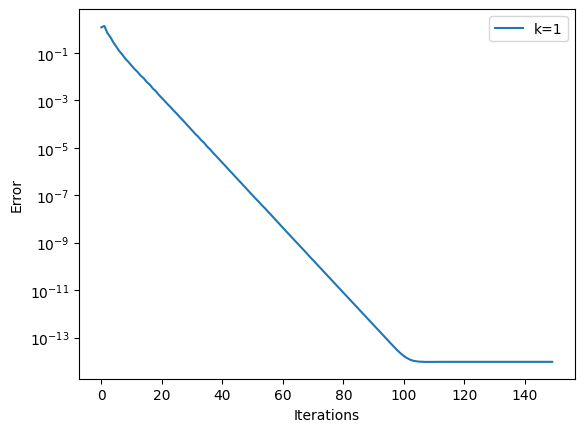

In [41]:
# REGULAR CG

def expand_symmetric(matrix):
    rows = np.concatenate([matrix.row, matrix.col])
    cols = np.concatenate([matrix.col, matrix.row])
    vals = np.concatenate([matrix.data, matrix.data])
    return scipy.sparse.coo_array((vals, (rows, cols)), shape=matrix.shape)

A = cpscipy.sparse.csc_matrix(scipy.io.mmread("A.mtx").tocsc())
cp_rng_glob = cp.random.RandomState(seed=1234)
cp.random.seed(1234)
b = cp_rng_glob.uniform(A.min(), A.max(), (A.shape[0], 1))
# b = cp.random.randn(A.shape[0]).T * A.data.mean().item() + A.data.std().item()

# J = cpscipy.sparse.csc_matrix(scipy.io.mmread("J.mtx").tocsc())
# H_inv = cpscipy.sparse.csc_matrix(scipy.sparse.linalg.inv(expand_symmetric(scipy.io.mmread("H.mtx")).tocsc()))
# A = J @ H_inv @ J.T
# b = cp.asarray(scipy.io.mmread("b.mtx"))

MAX_K = 18
INCREMENT = 3
ITMAX = 150

solver = RandomizedCG(A, b, ITMAX)

convergence_iters_a = cp.array([])
errors_a = cp.array([])
diff_with_best_basis_a = cp.array([])
error_history_a = []
x_a = []

# convergence_iters_b = cp.array([])
# errors_b = cp.array([])
# diff_with_best_basis_b = cp.array([])

k=1
convergence_iter_a, error_a, basis_errors_a, error_history_a, x_ak = solver.solve(k, 1e9, "estimated_norm")
plt.semilogy(cp.array(error_history_a).get(), label=f"k={k}")

# convergence_iter_b, error_b, basis_errors_b = solver.solve(k, 1e10)
# convergence_iters_b = cp.append(convergence_iters_b, convergence_iter_b)
# errors_b = cp.append(errors_b, error_b)
# diff_with_best_basis_b = cp.append(diff_with_best_basis_b, cp.min(basis_errors_b) - error_b)

print(k)

# plt.plot(cp.arange(1, MAX_K, INCREMENT), convergence_iters_a)
# plt.plot(cp.arange(1, MAX_K, INCREMENT), convergence_iters_b)
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()

## Code archive

In [ ]:
def solve_no_preconditioning(A, b, k, TOL):
    n = A.shape[0]
    A_bar = A
    B_bar = cp.tile(b, (1, k)) #  https://arxiv.org/pdf/1610.03871
    rng = cp.random.default_rng(seed=1234567)
    X_bar = cp.asarray(scipy.stats.ortho_group.rvs(dim=n, random_state=rng)[:,:k])
    X_bar *= B_bar.var() / (A_bar@X_bar).var()

    ITMAX = 50

    R = B_bar - A_bar @ X_bar
    P = R # Nonzero X_0 => use P = R instead of P = B_bar]

    converged = False
    i = 0
    for i in range(ITMAX):
        Gamma_i = R.T @ R
        Delta = P.T @ A_bar @ P
        Delta_inv = cp.linalg.inv(Delta)
        Alpha = Delta_inv @ Gamma_i
        X_bar = X_bar + P @ Alpha
        R = R - A_bar @ P @ Alpha

        R_norms = cp.linalg.norm(R, axis=0)
        min_norm = cp.min(R_norms)
        # print(min_norm)
        if (min_norm < TOL):
            converged = True
            # print(f"Converged in {i + 1} iterations. Error: {min_norm}")
            break

        Gamma_i1 = R.T @ R
        Gamma_i_inv = cp.linalg.inv(Gamma_i)
        Beta = Gamma_i_inv @ Gamma_i1
        Gamma_i = Gamma_i1
        P = R + P @ Beta

    X = X_bar

    if k == 1:
        x = X
    else:
        # Find optimal linear combination of the columns of X
        c = cp.Variable((k, 1))
        objective = cp.Minimize(cp.sum_squares(b - A @ X @ c))
        constraints = [cp.sum(c) == 1, c >= 0]
        prob = cp.Problem(objective, constraints)
        result = prob.solve()
        x = X @ c.value
    if not converged:
        # print("Didn't converge.")
        return (-i, error, basis_errors)
    error = cp.linalg.norm(b - A @ x)
    basis_errors = cp.tile(b, (1, k)) - A@X
    # print(f"Error of final linear combination solution: {error}")
    # print(f"Errors of each individual column of X_bar: {cp.linalg.norm(basis_errors, axis=0)}")
    return (i, error, basis_errors)

In [ ]:
# This replicates the ReSolve code (but simplifies some logic)

J = scipy.io.mmread("J.mtx").tocsc()
H = scipy.io.mmread("H.mtx").tocsc()
b = scipy.io.mmread("b.mtx")
A = J @ cpscipy.sparse.linalg.inv(H) @ J.T

k = 10
n = A.shape[0]

B = cp.tile(b, (1, k)) # Duplicate b across columns
rng = cp.random.default_rng(seed=12344567)
X = cpscipy.stats.ortho_group.rvs(dim=n, random_state=rng)[:,:k]
X *= B.var() / (A@X).var()

ITMAX = 30
TOL = 1e-12

R = B
S = B
W = B

R = R - A @ X
P = R # Nonzero X_0 => use P = R instead of P = B
Gamma_i = R.T @ R

W = A @ R
Delta = W.T @ R
Delta_inv = cp.linalg.inv(Delta)
Alpha = Delta_inv @ Gamma_i
Beta = cp.zeros((k, k))

for i in range(ITMAX):
    P = R + P @ Beta
    S = W + S @ Beta
    X = X + P @ Alpha
    R = R - S @ Alpha
    Gamma_i1 = R.T @ R

    R_norms = cp.linalg.norm(R, axis=0)
    min_norm = cp.min(R_norms)
    print(min_norm)
    if (min_norm < TOL):
        print(f"Converged in {i + 1} iterations. Error: {min_norm}")
        break

    W = A @ R

    Delta = W.T @ R
    Gamma_i_inv = cp.linalg.inv(Gamma_i)
    Beta = Gamma_i_inv @ Gamma_i1
    Gamma_i = Gamma_i1
    Alpha = cp.linalg.inv(Delta - Gamma_i @ cp.linalg.inv(Alpha) @ Beta) @ Gamma_i

AttributeError: module 'cupyx.scipy.sparse.linalg' has no attribute 'inv'

In [ ]:
# This implements the textbook CG algorithm

J = cpscipy.io.mmread("J.mtx").tocsc()
H = cpscipy.io.mmread("H.mtx").tocsc()
b = cpscipy.io.mmread("b.mtx")
A = J @ cpscipy.sparse.linalg.inv(H) @ J.T

n = A.shape[0]
k = 2

rng = cp.random.default_rng()
X = cpscipy.stats.ortho_group.rvs(dim=n, random_state=rng)[:,:k]
B = cp.tile(b, (1, k)) # Duplicate b across columns

ITMAX = 1
TOL = 1e-6

R = B - A @ X
P = R
for i in range(ITMAX):
    Gamma_i = R.T @ R
    Delta = P.T @ A @ P
    Delta_inv = cp.linalg.inv(Delta)
    Alpha = Delta_inv @ Gamma_i
    X = X + P @ Alpha
    R = R - A @ P @ Alpha

    R_norms = cp.linalg.norm(R, axis=0)
    min_norm = cp.min(R_norms)
    print(X)
    if (cp.min(R_norms) < TOL):
        print(f"Converged. Error: {cp.min(R_norms)}")
        break
    Gamma_i1 = R.T @ R
    Gamma_i_inv = cp.linalg.inv(Gamma_i)
    Beta = Gamma_i_inv @ Gamma_i1
    Gamma_i = Gamma_i1
    P = R + P @ Beta




Doing everything in residual space

In [91]:
# This replicates the ReSolve code (but simplifies some logic)
class RandomizedCG:
    def __init__(self, A, b, ITMAX=50):
        self.A = A
        self.b = b
        self.n = self.A.shape[0]

        self.D = cpscipy.sparse.diags(1 / cp.sqrt(self.A.diagonal())) # Diagonal scaling matrix
        self.A_bar = self.D @ self.A @ self.D

        self.b_norm = cp.linalg.norm(self.b)
        self.b_bar = 1 / self.b_norm * (self.D @ self.b) #  https://arxiv.org/pdf/1610.03871

        self.np_rng = np.random.default_rng(seed=1234567)

        self.ITMAX = ITMAX

    def reset_rng(self):
        self.cp_rng = cp.random.RandomState(seed=1234)

    def generate_initial_guess(self, B_bar, mode):
        k = B_bar.shape[1]
        match mode:
            case "estimated_norm":
                U = self.cp_rng.uniform(-1, 1, (self.n, k))
                X_bar = U
                X_bar = X_bar * cp.linalg.norm(B_bar) / cp.linalg.norm(self.A_bar @ X_bar)
            case "norm_scaling":
                U = self.cp_rng.uniform(-1, 1, (self.n, k))
                X_bar = U
                X_bar = X_bar / (cp.linalg.norm(X_bar) * cp.linalg.norm(B_bar) / cp.linalg.norm(self.A_bar))
            case "hadamard":
                rows = cp.arange(self.n)[:, cp.newaxis]
                cols = cp.arange(k)
                X_bar = (rows & (1 << cols) > 0).astype(cp.float64)
                X_bar *= (max - min)
                X_bar += min
                print(X_bar)

        return X_bar


    def solve(self, k, beta, guess_mode):
        self.reset_rng()

        penalty = cp.sqrt(beta) * cp.ones((1, k))

        eps = sys.float_info.epsilon
        assert(beta * self.n * eps < 0.02)

        B_bar_tiled = cp.tile(self.b_bar, (1, k))
        X_bar_0 = self.generate_initial_guess(B_bar_tiled, guess_mode)
        X_bar = cp.zeros((self.n, k))
        B_bar = B_bar_tiled - self.A_bar @ X_bar_0
        B_tiled = cp.tile(self.b, (1, k))
        # X_bar_tiled = X_bar + X_bar_0
        # X = self.b_norm * self.D @ X_bar_tiled

        TOL = 1e-999

        R_bar = B_bar - self.A_bar @ X_bar
        Gamma_i = R_bar.T @ R_bar
        P = R_bar # Nonzero X_0 => use P = R_bar instead of P = B_bar]

        converged = False
        error = 999999
        error_history = []
        for i in range(self.ITMAX):
            Delta = P.T @ self.A_bar @ P
            Delta_inv = cp.linalg.inv(Delta)
            Alpha = Delta_inv @ Gamma_i
            X_bar = X_bar + P @ Alpha
            R_bar = R_bar - self.A_bar @ P @ Alpha

            X_bar_tiled = X_bar + X_bar_0
            X = self.b_norm * self.D @ X_bar_tiled
            if k == 1:
                x = X
            else:
                # Find optimal linear combination of the columns of X
                AX_with_penalty = cp.vstack([self.A @ X, penalty])
                b_with_penalty = cp.vstack([self.b, cp.sqrt(beta)])
                cp.random.seed(1234)
                c, _, _, _ = cp.linalg.lstsq(AX_with_penalty, b_with_penalty)
                x = X @ c

            r = self.b - self.A @ x
            # error = cp.linalg.norm(r)
            error = cp.linalg.norm(r) / self.b_norm
            error_history = np.append(error_history, error)
            # print(f"iteration {i}, error {error}")
            if (error < TOL):
                converged = True
                # print(f"Converged in {i + 1} iterations. Error: {min_norm}")
                break

            Gamma_i1 = R_bar.T @ R_bar
            Gamma_i_inv = cp.linalg.inv(Gamma_i)
            Beta = Gamma_i_inv @ Gamma_i1
            Gamma_i = Gamma_i1
            P = R_bar + P @ Beta

        if not converged:
            i = -1
            # print("Didn't converge.")

        basis_errors = cp.linalg.norm(cp.tile(self.b, (1, k)) - A @ X, axis=0)
        # print(f"Error of final linear combination solution: {error}")
        # print(f"Errors of each individual column of X_bar: {cp.linalg.norm(basis_errors, axis=0)}")
        return (i, error, basis_errors, error_history, x)

In [92]:
# Run experiments and plot

def expand_symmetric(matrix):
    rows = np.concatenate([matrix.row, matrix.col])
    cols = np.concatenate([matrix.col, matrix.row])
    vals = np.concatenate([matrix.data, matrix.data])
    return scipy.sparse.coo_array((vals, (rows, cols)), shape=matrix.shape)

A = cpscipy.sparse.csc_matrix(scipy.io.mmread("A.mtx").tocsc())
cp_rng_glob = cp.random.RandomState(seed=1234)
cp.random.seed(1234)
b = cp_rng_glob.uniform(A.min(), A.max(), (A.shape[0], 1))
# b = cp.random.randn(A.shape[0]).T * A.data.mean().item() + A.data.std().item()

# J = cpscipy.sparse.csc_matrix(scipy.io.mmread("J.mtx").tocsc())
# H_inv = cpscipy.sparse.csc_matrix(scipy.sparse.linalg.inv(expand_symmetric(scipy.io.mmread("H.mtx")).tocsc()))
# A = J @ H_inv @ J.T
# b = cp.asarray(scipy.io.mmread("b.mtx"))

ks = 2 ** np.arange(7)
ITMAX = 150

solver = RandomizedCG(A, b, ITMAX)

convergence_iters_a = cp.array([])
errors_a = cp.array([])
# diff_with_best_basis_a = cp.array([])
error_history_a = []
x_a = []

# convergence_iters_b = cp.array([])
# errors_b = cp.array([])
# diff_with_best_basis_b = cp.array([])

for k in ks:
    convergence_iter_a, error_a, basis_errors_a, error_history_a, x_ak = solver.solve(k, 1e9, "norm_scaling")
    convergence_iters_a = cp.append(convergence_iters_a, convergence_iter_a)
    errors_a = cp.append(errors_a, error_a)
    # diff_with_best_basis_a = cp.append(diff_with_best_basis_a, cp.min(basis_errors_a) - error_a)
    x_a.append(x_ak)
    plt.semilogy(cp.array(error_history_a).get(), label=f"k={k}")

    # convergence_iter_b, error_b, basis_errors_b = solver.solve(k, 1e10)
    # convergence_iters_b = cp.append(convergence_iters_b, convergence_iter_b)
    # errors_b = cp.append(errors_b, error_b)
    # diff_with_best_basis_b = cp.append(diff_with_best_basis_b, cp.min(basis_errors_b) - error_b)

    print(k)

# plt.plot(cp.arange(1, MAX_K, INCREMENT), convergence_iters_a)
# plt.plot(cp.arange(1, MAX_K, INCREMENT), convergence_iters_b)
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()

FileNotFoundError: The source file does not exist: A.mtx